# 02 — Pré-processamento: Normalização Temporal T=100

**Objetivo:** Carregar o manifest.csv (gerado no notebook 01), filtrar amostras válidas,
normalizar todas as sequências para T=100 frames via interpolação linear, e salvar
o dataset final em formato `.npz`.

**Estratégia de normalização:**
- Se T_orig > 100: subamostragem por interpolação linear
- Se T_orig < 100: upsampling por interpolação linear  
- Se T_orig == 100: mantém como está
- NaNs são preenchidos por interpolação linear antes da normalização

**Output:**
- `data/ravdess_landmarks_kaggle/01_processed_T100/dataset_T100.npz`
  - X: shape (N, 100, D)
  - y: shape (N,) — emotion code 0-indexed
  - actor_ids: shape (N,)

In [13]:
import sys, os

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: c:\source\vitmodel\vit-emot-poc


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.ravdess_utils import load_landmark_csv, EMOTION_MAP, EMOTION_LABELS
from src.temporal import normalize_sequence_length, build_dataset_T100

print("Imports OK")

Imports OK


## 2.1 Carregar Manifest

In [15]:
QC_DIR = os.path.join(ROOT, 'data', 'ravdess_landmarks_kaggle', '03_qc')
OUT_DIR = os.path.join(ROOT, 'data', 'ravdess_landmarks_kaggle', '01_processed_T100')
os.makedirs(OUT_DIR, exist_ok=True)

manifest = pd.read_csv(os.path.join(QC_DIR, 'manifest.csv'))
print(f"Manifest carregado: {manifest.shape}")

# Filtrar amostras válidas
valid = manifest[manifest['status_ok'] == True].copy()
print(f"Amostras válidas: {len(valid)}")
valid.head()

Manifest carregado: (2452, 10)
Amostras válidas: 2452


,filepath,filename,actor_id,emotion_code,emotion_label,n_frames,n_features,has_nan,status_ok,parse_error
0,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-01.csv,1,1,neutral,98,712,False,True,NaN
1,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-02.csv,2,1,neutral,109,712,False,True,NaN
2,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-03.csv,3,1,neutral,103,712,False,True,NaN
3,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-04.csv,4,1,neutral,99,712,False,True,NaN
4,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-05.csv,5,1,neutral,108,712,False,True,NaN


## 2.2 Sanity Check: inspecionar uma amostra antes da normalização

In [16]:
# Carregar primeira amostra para inspeção
sample_row = valid.iloc[0]
sample_df = load_landmark_csv(sample_row['filepath'])
numeric_cols = sample_df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Arquivo: {sample_row['filename']}")
print(f"Emoção: {sample_row['emotion_label']} (code={sample_row['emotion_code']})")
print(f"Ator: {sample_row['actor_id']}")
print(f"Frames: {len(sample_df)}")
print(f"Features numéricas: {len(numeric_cols)}")
print(f"\nPrimeiras 5 colunas numéricas: {numeric_cols[:5]}")

sample_df[numeric_cols].describe()

Arquivo: 01-01-01-01-01-01-01.csv
Emoção: neutral (code=1)
Ator: 1
Frames: 98
Features numéricas: 712

Primeiras 5 colunas numéricas: ['frame', 'timestamp', 'confidence', 'gaze_0_x', 'gaze_0_y']


,frame,timestamp,confidence,gaze_0_x,gaze_0_y,gaze_0_z,gaze_1_x,gaze_1_y,gaze_1_z,gaze_angle_x,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
count,98.000000,98.000000,9.800000e+01,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,98.0,98.000000,98.000000,98.0,98.000000,98.000000,98.000000,98.000000,98.0,98.000000
mean,49.500000,1.618296,9.800000e-01,0.095934,0.219326,-0.968304,-0.097679,0.207397,-0.971387,-0.000867,...,0.0,0.877551,0.275510,0.0,0.051020,0.020408,0.459184,0.846939,0.0,0.448980
std,28.434134,0.948758,3.347793e-16,0.054445,0.044304,0.014348,0.033225,0.050606,0.015072,0.035428,...,0.0,0.329489,0.449068,0.0,0.221171,0.142119,0.500893,0.361898,0.0,0.499947
min,1.000000,0.000000,9.800000e-01,0.009605,0.151913,-0.986618,-0.225913,0.127612,-0.990195,-0.074000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,25.250000,0.809250,9.800000e-01,0.038181,0.180133,-0.982459,-0.117252,0.172234,-0.981052,-0.032750,...,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.0,0.000000
50%,49.500000,1.618500,9.800000e-01,0.099988,0.221399,-0.967210,-0.089202,0.214851,-0.971737,-0.005500,...,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.0,0.000000
75%,73.750000,2.427500,9.800000e-01,0.151628,0.237618,-0.958597,-0.078319,0.228436,-0.968620,0.039250,...,0.0,1.000000,1.000000,0.0,0.000000,0.000000,1.000000,1.000000,0.0,1.000000
max,98.000000,3.237000,9.800000e-01,0.176230,0.377961,-0.920763,-0.042760,0.383726,-0.895387,0.059000,...,0.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,0.0,1.000000


## 2.3 Construir Dataset T=100

In [17]:
%%time
TARGET_T = 100

X, y, meta = build_dataset_T100(
    manifest_df=valid,
    load_csv_fn=load_landmark_csv,
    target_len=TARGET_T,
    verbose=True,
)

print(f"\nDataset final:")
print(f"  X shape: {X.shape}  (N={X.shape[0]}, T={X.shape[1]}, D={X.shape[2]})")
print(f"  y shape: {y.shape}")
print(f"  y classes únicas: {np.unique(y)}")
print(f"  dtype X: {X.dtype}, dtype y: {y.dtype}")

Construindo dataset T=100: 100%|██████████| 2452/2452 [01:00<00:00, 40.55it/s]


Dataset construído: 2452 amostras, 0 puladas

Dataset final:
  X shape: (2452, 100, 712)  (N=2452, T=100, D=712)
  y shape: (2452,)
  y classes únicas: [0 1 2 3 4 5 6 7]
  dtype X: float32, dtype y: int64
CPU times: total: 1min
Wall time: 1min


In [18]:
# Extrair actor_ids do metadata
actor_ids = np.array([m['actor_id'] for m in meta], dtype=np.int64)
emotion_labels_list = [m['emotion_label'] for m in meta]

# Verificar distribuição de classes
print("Distribuição de classes no dataset final:")
for code in sorted(np.unique(y)):
    label = EMOTION_MAP.get(code + 1, f"unknown_{code}")
    count = (y == code).sum()
    print(f"  {code} ({label}): {count} amostras")

Distribuição de classes no dataset final:
  0 (neutral): 188 amostras
  1 (calm): 376 amostras
  2 (happy): 376 amostras
  3 (sad): 376 amostras
  4 (angry): 376 amostras
  5 (fearful): 376 amostras
  6 (disgust): 192 amostras
  7 (surprised): 192 amostras


## 2.4 Sanity Check: valores do dataset

In [19]:
# Checks básicos
print("Sanity checks:")
print(f"  NaN no X? {np.isnan(X).any()}")
print(f"  Inf no X? {np.isinf(X).any()}")
print(f"  X min: {X.min():.4f}")
print(f"  X max: {X.max():.4f}")
print(f"  X mean: {X.mean():.4f}")
print(f"  X std: {X.std():.4f}")

# Verificar se todas as amostras têm o mesmo número de features
print(f"\n  Todas as amostras com T={TARGET_T}? {X.shape[1] == TARGET_T}")
print(f"  D (features): {X.shape[2]}")

Sanity checks:
  NaN no X? False
  Inf no X? False
  X min: -196.6000
  X max: 1876.4910
  X mean: 392.6376
  X std: 452.8594

  Todas as amostras com T=100? True
  D (features): 712


## 2.5 Visualizações: trajetórias temporais de landmarks

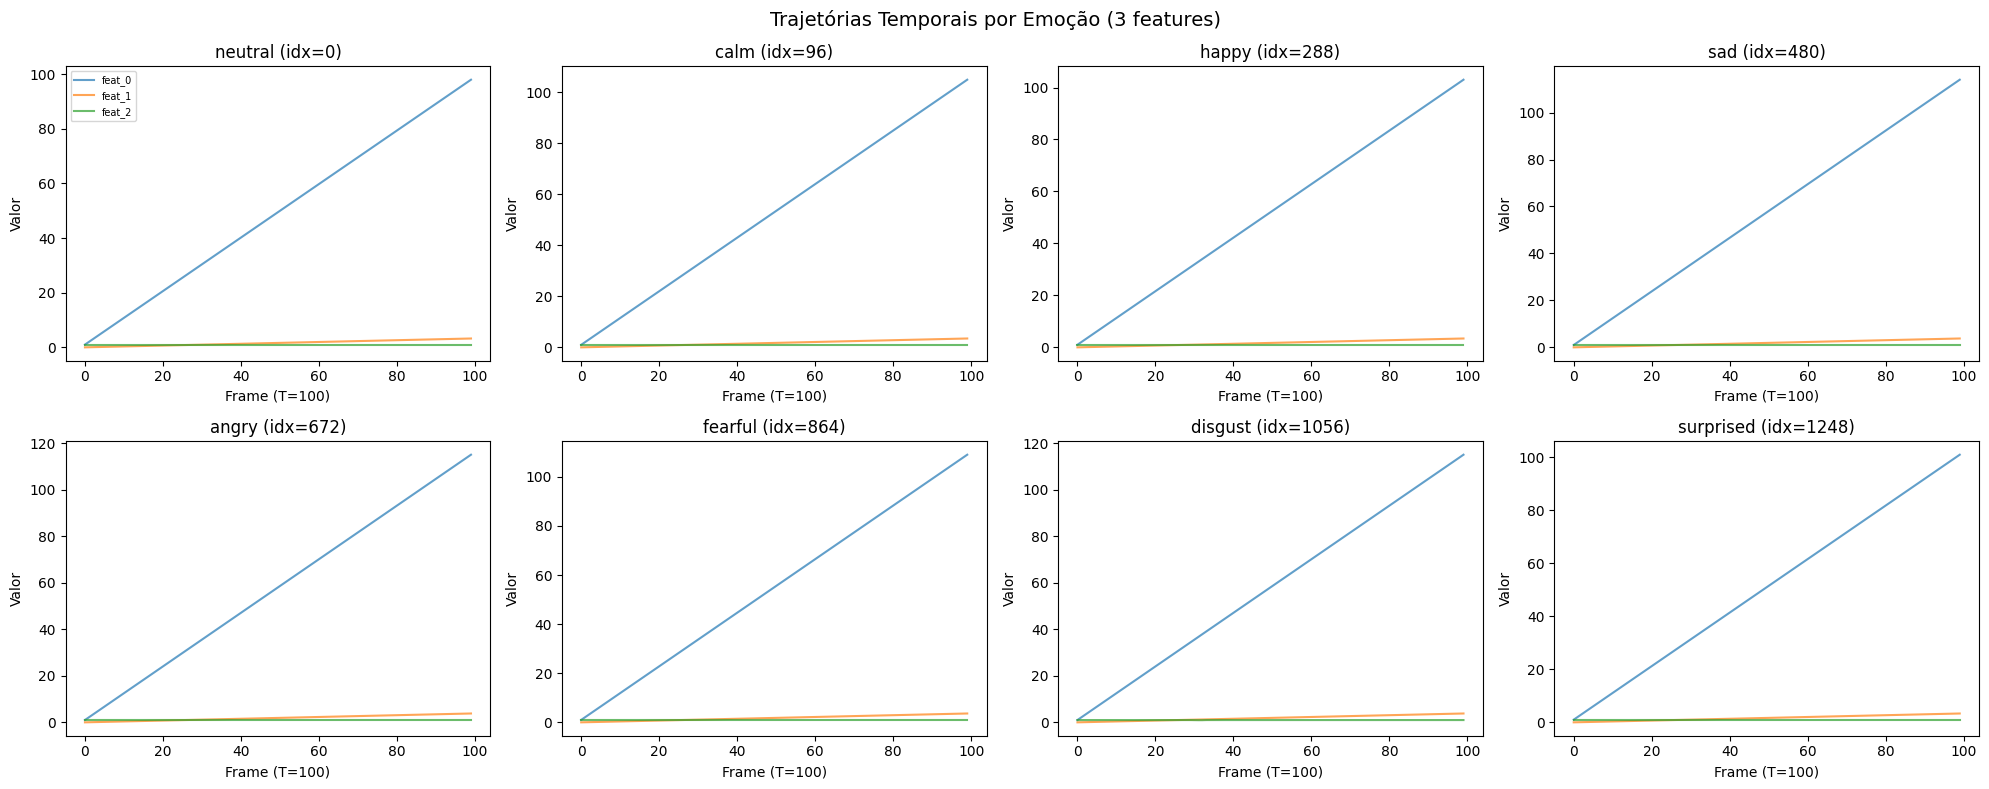

In [20]:
# Visualizar trajetória temporal de algumas features para diferentes emoções
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

# Escolher 1 amostra de cada emoção
n_features_to_plot = 3  # Mostrar 3 features por amostra

for emo_idx in range(min(8, len(np.unique(y)))):
    # Encontrar primeira amostra desta emoção
    mask = y == emo_idx
    if not mask.any():
        continue
    sample_idx = np.where(mask)[0][0]
    sample = X[sample_idx]  # (T, D)
    label = EMOTION_MAP.get(emo_idx + 1, f"emo_{emo_idx}")

    ax = axes[emo_idx]
    for feat_i in range(min(n_features_to_plot, sample.shape[1])):
        ax.plot(sample[:, feat_i], alpha=0.7, label=f"feat_{feat_i}")
    ax.set_title(f"{label} (idx={sample_idx})")
    ax.set_xlabel('Frame (T=100)')
    ax.set_ylabel('Valor')
    if emo_idx == 0:
        ax.legend(fontsize=7)

plt.suptitle('Trajetórias Temporais por Emoção (3 features)', fontsize=14)
plt.tight_layout()
plt.show()

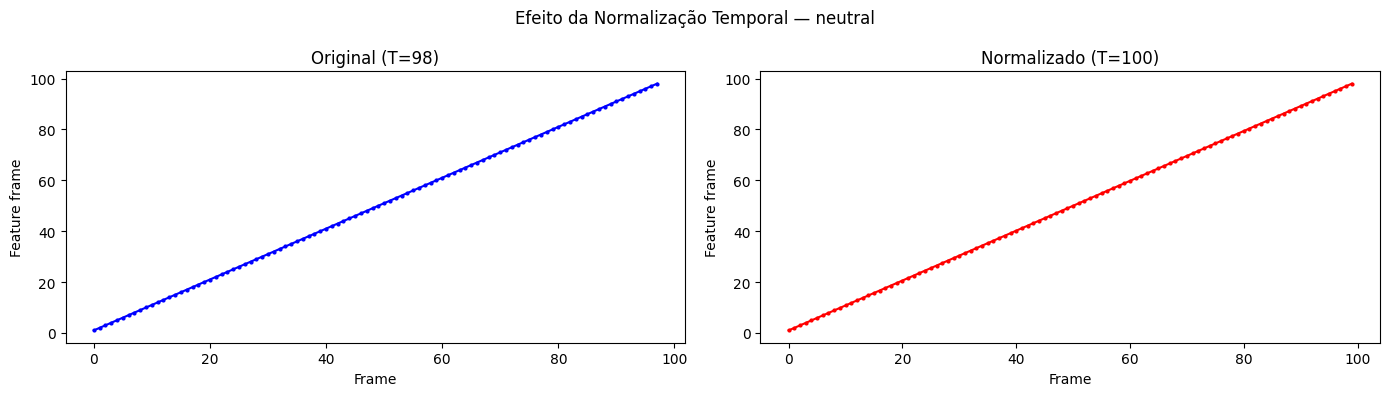

In [21]:
# Visualizar efeito da normalização temporal em uma amostra
sample_row = valid.iloc[0]
df_orig = load_landmark_csv(sample_row['filepath'])
numeric_cols = df_orig.select_dtypes(include=[np.number]).columns.tolist()
orig_vals = df_orig[numeric_cols].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_idx = 0

axes[0].plot(orig_vals[:, feat_idx], 'b-o', markersize=2)
axes[0].set_title(f'Original (T={orig_vals.shape[0]})')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel(f'Feature {numeric_cols[feat_idx]}')

# Versão normalizada
norm_vals = normalize_sequence_length(orig_vals, TARGET_T)
axes[1].plot(norm_vals[:, feat_idx], 'r-o', markersize=2)
axes[1].set_title(f'Normalizado (T={TARGET_T})')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel(f'Feature {numeric_cols[feat_idx]}')

plt.suptitle(f'Efeito da Normalização Temporal — {sample_row["emotion_label"]}', fontsize=12)
plt.tight_layout()
plt.show()

## 2.6 Salvar Dataset

In [22]:
# Salvar em formato .npz
out_path = os.path.join(OUT_DIR, 'dataset_T100.npz')
np.savez_compressed(
    out_path,
    X=X,
    y=y,
    actor_ids=actor_ids,
    emotion_labels=np.array(emotion_labels_list),
)

# Verificar tamanho
size_mb = os.path.getsize(out_path) / (1024 * 1024)
print(f"Dataset salvo em: {out_path}")
print(f"Tamanho: {size_mb:.1f} MB")
print(f"Shape: X={X.shape}, y={y.shape}, actor_ids={actor_ids.shape}")

print("\nNotebook 02 concluído com sucesso!")

Dataset salvo em: c:\source\vitmodel\vit-emot-poc\data\ravdess_landmarks_kaggle\01_processed_T100\dataset_T100.npz
Tamanho: 534.0 MB
Shape: X=(2452, 100, 712), y=(2452,), actor_ids=(2452,)

Notebook 02 concluído com sucesso!
